<a href="https://colab.research.google.com/github/larissavaladao/time_series_curuai/blob/main/5.%20parameters_by_period/1.set_periods.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# import packages

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Export directory

In [3]:
exp_directory = r"C:\Users\l_v_v\Documents\GitHub\time_series_curuai\datasets\Parameters Time series\Water Period Definitions"

# Import data

***Agência Nacional de Águas - ANA***/
Superintendência de Gestão da Rede Hidrometeorológica-SGH/
Sistema de Informações Hidrológicas - Versão WEB

- NivelConsistencia: 1 = Bruto, 2 = Consistido
- MediaDiaria: Indica se a medição é média diaria ou instantânea.  0 = Não , 1 = Sim
- TipoMedicaoCotas: 1 = Escala, 2 = Linígrafo, 3 = Data Logger, 5 = Escala SMS
- Status: 0 = Branco, 1 = Real, 2 = Estimado, 3 = Duvidoso, 4 = Régua Seca

Óbidos - Cotas\
`Código da Estação:17050001`

In [4]:
data_directory = "C:/Users/l_v_v/Documents/GitHub/time_series_curuai/datasets/HidroWeb"

In [5]:
#dados obidos = cotas
#eliminar dados duplicados para o mesmo dia
obidos = pd.read_csv(os.path.join(data_directory,'17050001_Cotas.csv')).drop_duplicates(subset=['Data'])
# obidos = pd.read_csv('/content/drive/MyDrive/CURUAI_PROCESS/17050001_Cotas.csv').drop_duplicates(subset=['Data'])
obidos = obidos[['EstacaoCodigo', 'Data',  'Maxima', 'Minima', 'Media' ]].copy()
obidos['Data'] = pd.to_datetime(obidos['Data'],dayfirst=True)
obidos['location'] = "Óbidos"
obidos

,EstacaoCodigo,Data,Maxima,Minima,Media,location
0,17050001,2025-07-01,766.0,724.0,749.0,Óbidos
3,17050001,2025-06-01,778.0,764.0,772.0,Óbidos
6,17050001,2025-05-01,778.0,760.0,773.0,Óbidos
9,17050001,2025-04-01,758.0,686.0,724.0,Óbidos
12,17050001,2025-03-01,684.0,548.0,625.0,Óbidos
...,...,...,...,...,...,...
2009,17050001,1968-06-01,648.0,583.0,617.0,Óbidos
2011,17050001,1968-05-01,646.0,575.0,621.0,Óbidos
2013,17050001,1968-04-01,570.0,478.0,521.0,Óbidos
2015,17050001,1968-03-01,478.0,401.0,436.0,Óbidos


Curuai - Cotas\
`Código da Estação:17060000`

In [6]:
# dados curuai = cotas
#eliminar dados duplicados para o mesmo dia
# curuai = pd.read_csv('/content/drive/MyDrive/CURUAI_PROCESS/17060000_Cotas.csv').drop_duplicates(subset=['Data'])
curuai = pd.read_csv(os.path.join(data_directory,'17060000_Cotas.csv')).drop_duplicates(subset=['Data'])
curuai = curuai[['EstacaoCodigo', 'Data',  'Maxima', 'Minima', 'Media' ]].copy()
curuai['Data'] = pd.to_datetime(curuai['Data'],dayfirst=True)
curuai['location'] = "Curuai"
curuai

,EstacaoCodigo,Data,Maxima,Minima,Media,location
0,17060000,2019-03-01,NaN,NaN,NaN,Curuai
4,17060000,2019-02-01,904.0,805.0,848.0,Curuai
8,17060000,2019-01-01,805.0,683.0,747.0,Curuai
12,17060000,2018-12-01,682.0,465.0,569.0,Curuai
16,17060000,2018-11-01,461.0,418.0,431.0,Curuai
...,...,...,...,...,...,...
1383,17060000,1983-01-01,693.0,597.0,649.0,Curuai
1387,17060000,1982-12-01,590.0,489.0,540.0,Curuai
1391,17060000,1982-11-01,NaN,NaN,NaN,Curuai
1395,17060000,1982-10-01,NaN,NaN,NaN,Curuai


In [7]:
# concatenar dados das duas estações e restringir para o periodo de tempo que há dados em curuai
cotas = obidos.merge(curuai,on="Data", how = 'right', suffixes=('_obidos','_curuai'))
cotas

,EstacaoCodigo_obidos,Data,Maxima_obidos,Minima_obidos,Media_obidos,location_obidos,EstacaoCodigo_curuai,Maxima_curuai,Minima_curuai,Media_curuai,location_curuai
0,17050001,2019-03-01,700.0,636.0,668.0,Óbidos,17060000,NaN,NaN,NaN,Curuai
1,17050001,2019-02-01,634.0,530.0,577.0,Óbidos,17060000,904.0,805.0,848.0,Curuai
2,17050001,2019-01-01,529.0,410.0,473.0,Óbidos,17060000,805.0,683.0,747.0,Curuai
3,17050001,2018-12-01,407.0,170.0,301.0,Óbidos,17060000,682.0,465.0,569.0,Curuai
4,17050001,2018-11-01,162.0,90.0,112.0,Óbidos,17060000,461.0,418.0,431.0,Curuai
...,...,...,...,...,...,...,...,...,...,...,...
418,17050001,1983-01-01,409.0,318.0,366.0,Óbidos,17060000,693.0,597.0,649.0,Curuai
419,17050001,1982-12-01,311.0,184.0,246.0,Óbidos,17060000,590.0,489.0,540.0,Curuai
420,17050001,1982-11-01,176.0,143.0,155.0,Óbidos,17060000,NaN,NaN,NaN,Curuai
421,17050001,1982-10-01,308.0,142.0,217.0,Óbidos,17060000,NaN,NaN,NaN,Curuai


In [8]:
# reajustar indices da tabela para gerar gráfico
cotas = cotas.reset_index(drop=True).dropna()
cotas = cotas[['Maxima_obidos', 'Minima_obidos', 'Media_obidos',
        'Maxima_curuai', 'Minima_curuai', 'Media_curuai']]
cotas.columns = ['Max Óbidos', 'Min Óbidos', 'Mean Óbidos',
        'Max Curuai', 'Min Curuai', 'Mean Curuai']


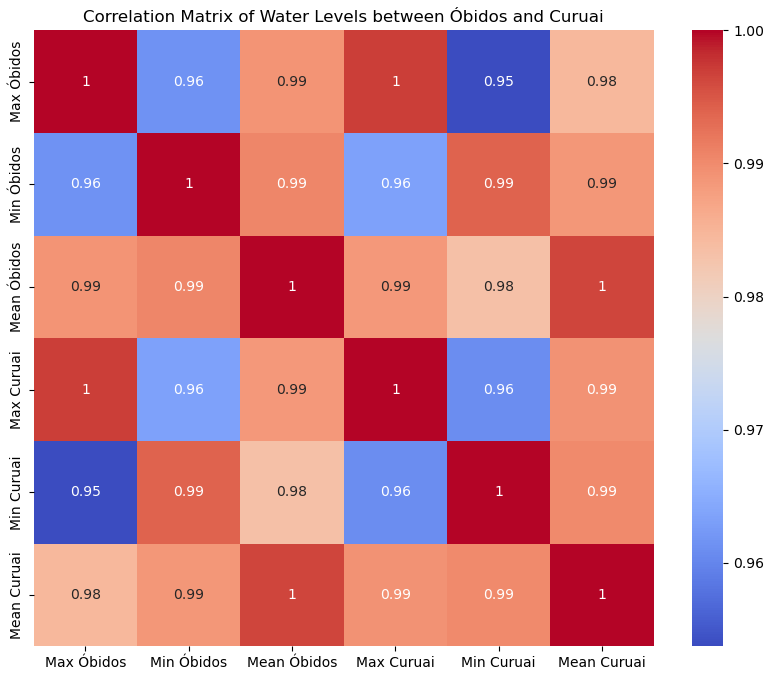

In [9]:
plt.figure(figsize=(10, 8))
sns.heatmap(cotas.corr(), annot=True, cmap='coolwarm')
plt.savefig(os.path.join(exp_directory, 'correlation_matrix.png'),dpi=300)
plt.title('Correlation Matrix of Water Levels between Óbidos and Curuai')
plt.show()

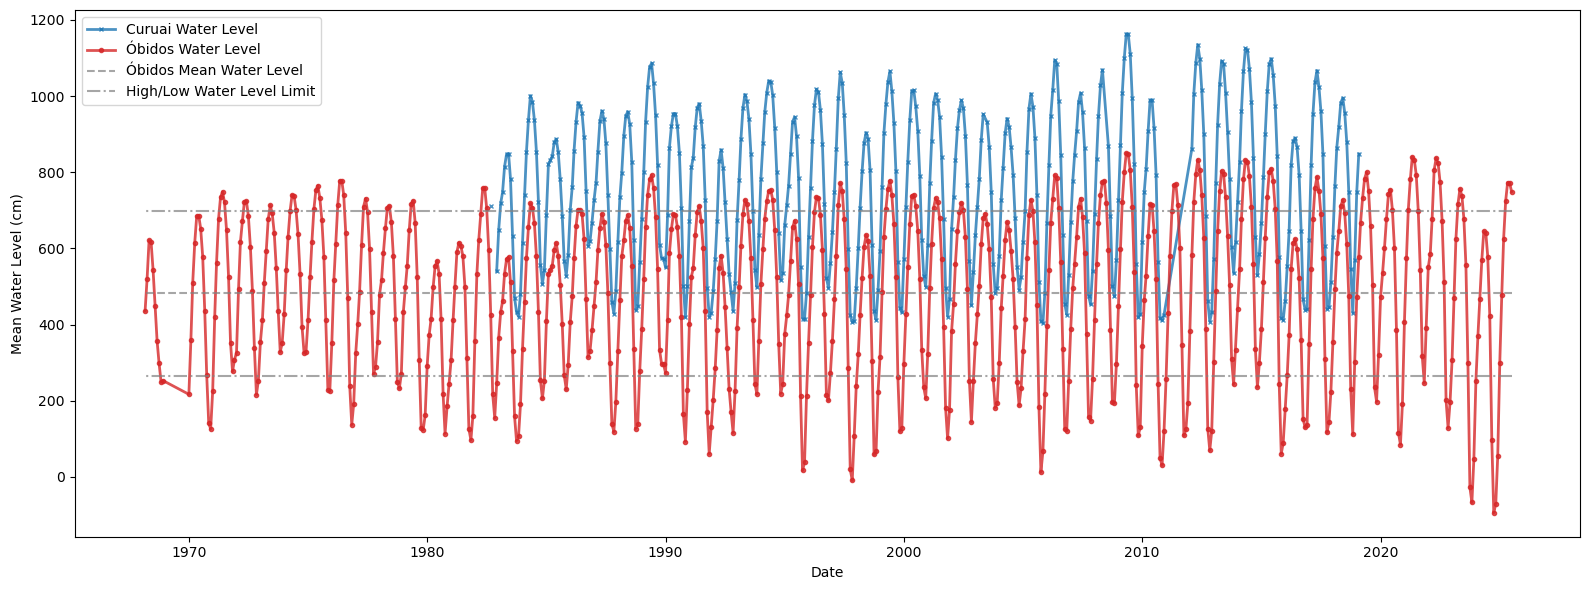

In [26]:
#comparar dados = seguem o mesmo padrão, aproximadamente
# grafico de linhas


fig, ax = plt.subplots(figsize=(16, 6))

    # Plot predictions
ax.plot(curuai['Data'], curuai['Media'],
            color='#1f77b4',marker="x",markersize = 2.5,  linestyle='solid', linewidth=2, alpha=0.8, label='Curuai Water Level')
ax.plot(obidos['Data'], obidos['Media'],
            color='#d62728', marker="o",markersize = 3,linestyle='solid', linewidth=2, alpha=0.8, label='Óbidos Water Level')
media = [float(obidos["Media"].mean())] * len(obidos["Media"])
ax.plot(obidos['Data'],media,color='grey', linestyle='--', linewidth=1.5, alpha=0.7, label='Óbidos Mean Water Level')
media = [float(obidos["Media"].mean() + ( obidos["Media"].std()))] * len(obidos["Media"])
ax.plot(obidos['Data'],media,color='grey', linestyle='-.', linewidth=1.5, alpha=0.7, label='High/Low Water Level Limit' )
media = [float(obidos["Media"].mean() - ( obidos["Media"].std()))] * len(obidos["Media"])
ax.plot(obidos['Data'],media,color='grey', linestyle='-.', linewidth=1.5, alpha=0.7 )

ax.set_xlabel('Date')
ax.set_ylabel('Mean Water Level (cm)')
ax.legend(loc='upper left')

plt.tight_layout()
plt.savefig(os.path.join(exp_directory,f"correlation.jpg"),dpi=300)
plt.show()
plt.close()

In [22]:
print('media obidos: ', obidos["Media"].mean())
print('std obidos: ', obidos["Media"].std())
print('obidos lim superior: ', obidos["Media"].mean() + ( obidos["Media"].std()))
print('obidos lim inferior: ', obidos["Media"].mean() - (obidos["Media"].std()))

media obidos:  481.9778434268833
std obidos:  216.01084329172616
obidos lim superior:  697.9886867186094
obidos lim inferior:  265.96700013515715


# Trabalhar com dados de Obidos

In [27]:
# adicionar periodos de água a partir de valores estabelecidos a partir do gráfico
def set_period(row):
  obidos_media = obidos["Media"].mean()
  obidos_std = obidos["Media"].std()
  media = row['Media']
  data = row['Data']
  if media > obidos["Media"].mean() + ( obidos["Media"].std()):
    return 'HW'
  elif media < obidos["Media"].mean() - ( obidos["Media"].std()):
    return 'LW'
  else:
    return "T"


In [28]:
# obter dados de óbidos apenas para o periodo entre 2000 e 2024
obidos_att = obidos.loc[(obidos['Data'].dt.year >= 1985) & (obidos['Data'].dt.year < 2026)].copy()
obidos_att = obidos_att.sort_values(by='Data').reset_index(drop=True)
obidos_att['water_period'] = obidos_att.apply(lambda row: set_period(row),axis = 1)
obidos_att

,EstacaoCodigo,Data,Maxima,Minima,Media,location,water_period
0,17050001,1985-01-01,505.0,315.0,409.0,Óbidos,T
1,17050001,1985-02-01,545.0,510.0,534.0,Óbidos,T
2,17050001,1985-03-01,556.0,528.0,543.0,Óbidos,T
3,17050001,1985-04-01,562.0,550.0,555.0,Óbidos,T
4,17050001,1985-05-01,620.0,557.0,597.0,Óbidos,T
...,...,...,...,...,...,...,...
482,17050001,2025-03-01,684.0,548.0,625.0,Óbidos,T
483,17050001,2025-04-01,758.0,686.0,724.0,Óbidos,HW
484,17050001,2025-05-01,778.0,760.0,773.0,Óbidos,HW
485,17050001,2025-06-01,778.0,764.0,772.0,Óbidos,HW


<Axes: xlabel='Data', ylabel='Media'>

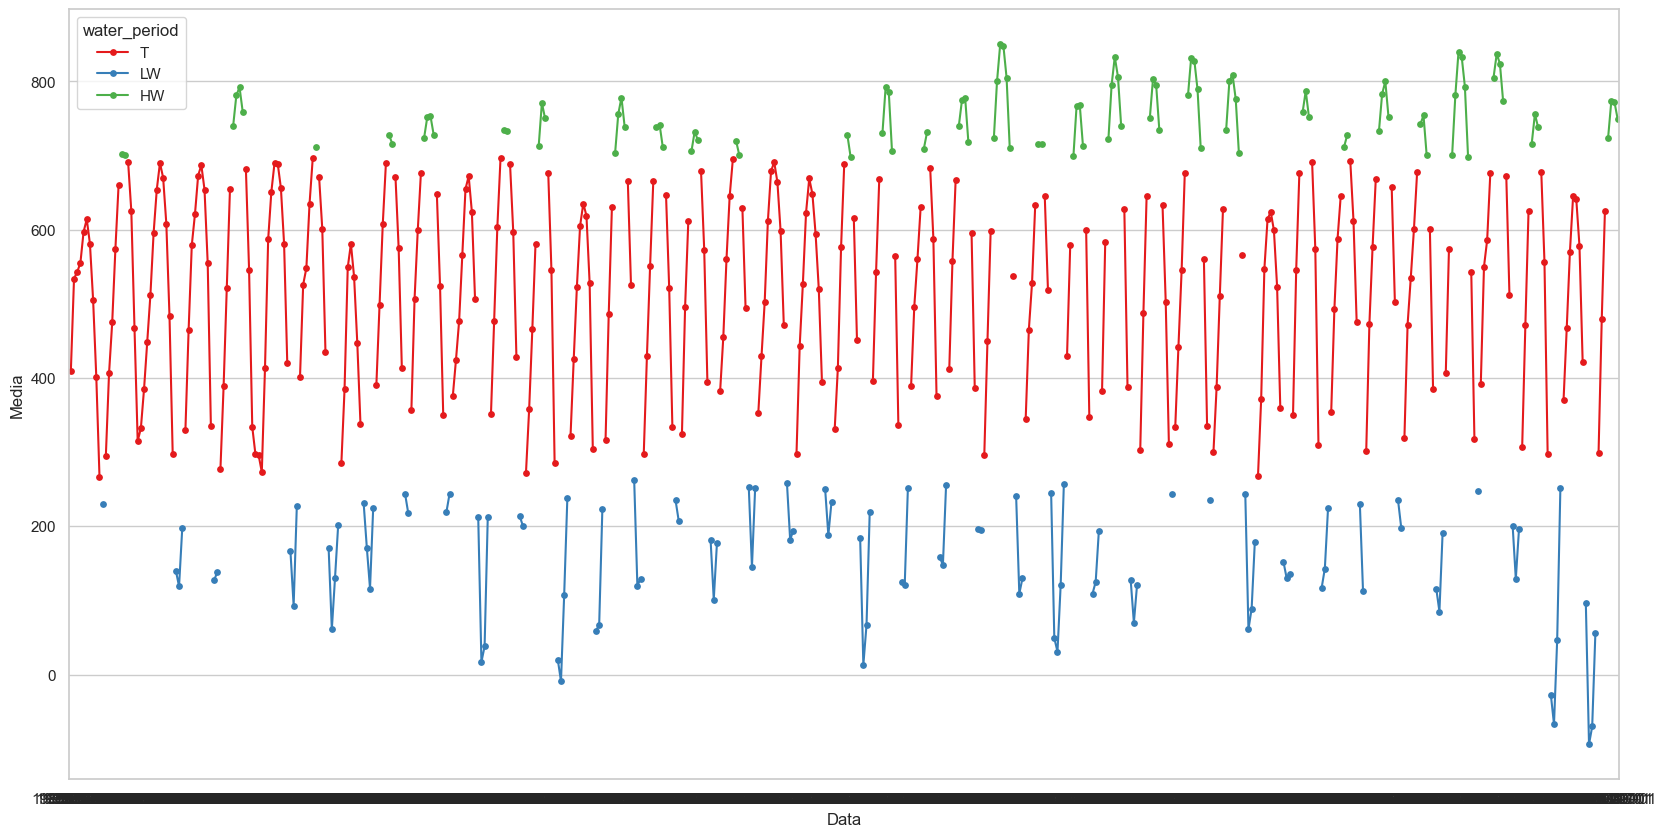

In [29]:
sns.set_theme(style="whitegrid",rc={'figure.figsize':(20,10)})
# sns.pointplot(data=obidos_att,x = obidos_att['Data'],y = obidos_att['Media'],  linewidth=1.5)
sns.pointplot(data=obidos_att,x = obidos_att['Data'],y = obidos_att['Media'], hue = obidos_att['water_period'], palette="Set1", linewidth=1.5)


In [30]:
obidos_att['longitude'] = -55.5131
obidos_att['latitude'] = -1.9192

In [31]:
sub = obidos_att[0:14]
sub

,EstacaoCodigo,Data,Maxima,Minima,Media,location,water_period,longitude,latitude
0,17050001,1985-01-01,505.0,315.0,409.0,Óbidos,T,-55.5131,-1.9192
1,17050001,1985-02-01,545.0,510.0,534.0,Óbidos,T,-55.5131,-1.9192
2,17050001,1985-03-01,556.0,528.0,543.0,Óbidos,T,-55.5131,-1.9192
3,17050001,1985-04-01,562.0,550.0,555.0,Óbidos,T,-55.5131,-1.9192
4,17050001,1985-05-01,620.0,557.0,597.0,Óbidos,T,-55.5131,-1.9192
5,17050001,1985-06-01,620.0,606.0,614.0,Óbidos,T,-55.5131,-1.9192
6,17050001,1985-07-01,605.0,551.0,581.0,Óbidos,T,-55.5131,-1.9192
7,17050001,1985-08-01,550.0,462.0,505.0,Óbidos,T,-55.5131,-1.9192
8,17050001,1985-09-01,461.0,336.0,401.0,Óbidos,T,-55.5131,-1.9192
9,17050001,1985-10-01,332.0,230.0,267.0,Óbidos,T,-55.5131,-1.9192


<Axes: xlabel='Data', ylabel='Media'>

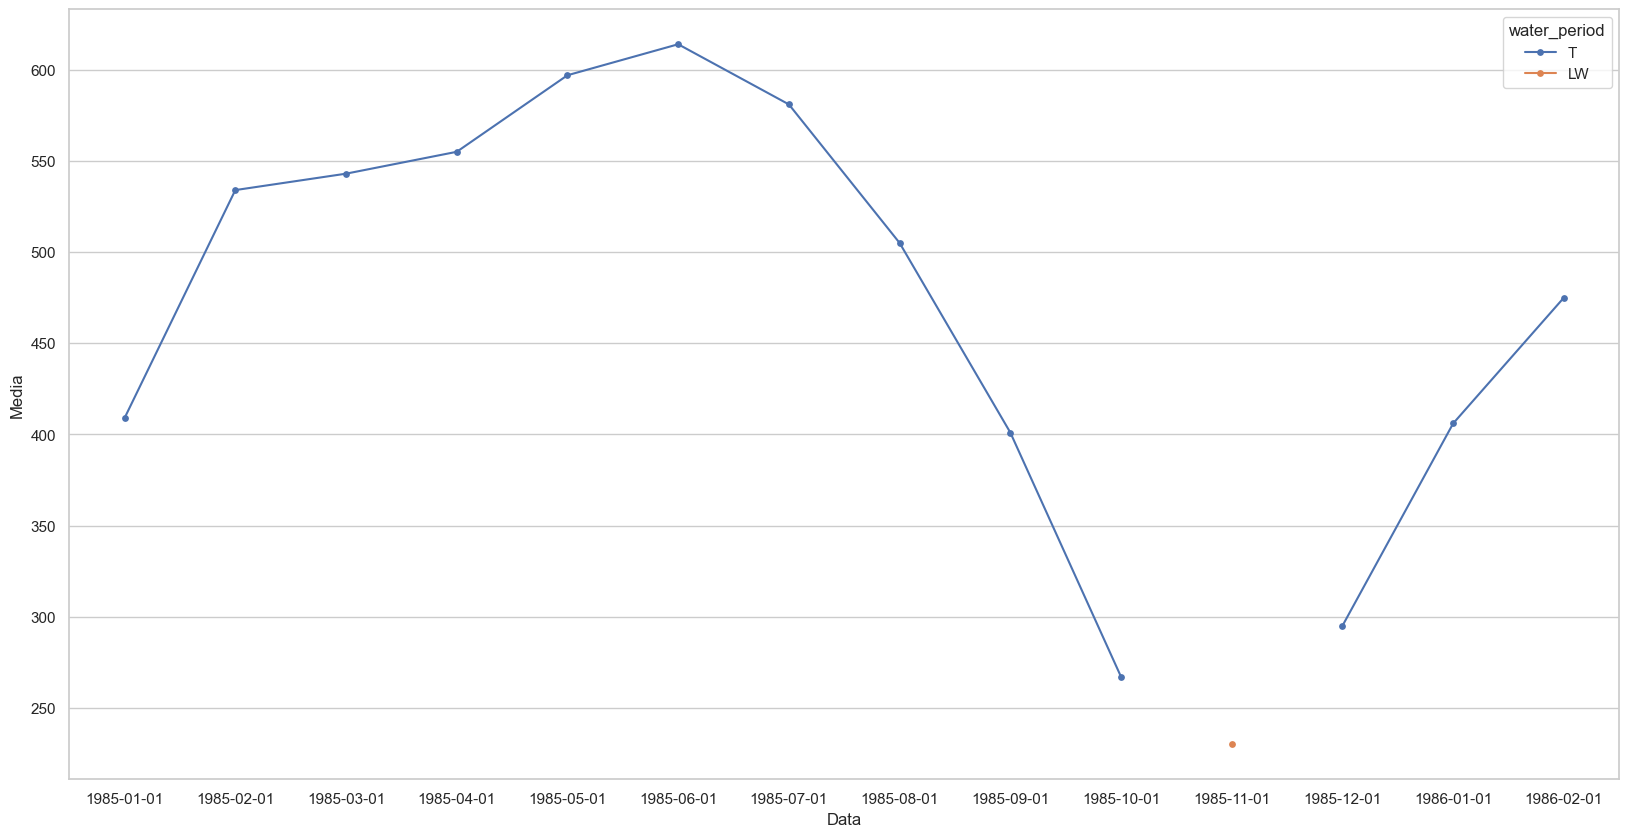

In [32]:
sns.pointplot(x = sub['Data'],y = sub['Media'],hue = sub['water_period'],  linewidth=1.5)

In [33]:
obidos_att['Change'] =   pd.DatetimeIndex(obidos_att.Data).asi8

obidos_att


,EstacaoCodigo,Data,Maxima,Minima,Media,location,water_period,longitude,latitude,Change
0,17050001,1985-01-01,505.0,315.0,409.0,Óbidos,T,-55.5131,-1.9192,473385600000000000
1,17050001,1985-02-01,545.0,510.0,534.0,Óbidos,T,-55.5131,-1.9192,476064000000000000
2,17050001,1985-03-01,556.0,528.0,543.0,Óbidos,T,-55.5131,-1.9192,478483200000000000
3,17050001,1985-04-01,562.0,550.0,555.0,Óbidos,T,-55.5131,-1.9192,481161600000000000
4,17050001,1985-05-01,620.0,557.0,597.0,Óbidos,T,-55.5131,-1.9192,483753600000000000
...,...,...,...,...,...,...,...,...,...,...
482,17050001,2025-03-01,684.0,548.0,625.0,Óbidos,T,-55.5131,-1.9192,1740787200000000000
483,17050001,2025-04-01,758.0,686.0,724.0,Óbidos,HW,-55.5131,-1.9192,1743465600000000000
484,17050001,2025-05-01,778.0,760.0,773.0,Óbidos,HW,-55.5131,-1.9192,1746057600000000000
485,17050001,2025-06-01,778.0,764.0,772.0,Óbidos,HW,-55.5131,-1.9192,1748736000000000000


In [34]:
from sklearn.linear_model import LinearRegression
ols = LinearRegression()

date_lim_inf = []
date_lim_sup = []

for i in range(0,len(obidos_att)-1):
  y = obidos_att['Change'][i:i+2].copy()
  X = np.array(obidos_att['Media'][i:i+2]).reshape(-1, 1).copy()
  ols_fit = ols.fit(X, y)

  date = (ols_fit.coef_ * (obidos["Media"].mean() - ( obidos["Media"].std()))) + ols_fit.intercept_
  date2 = (ols_fit.coef_ * (obidos["Media"].mean() + ( obidos["Media"].std()))) + ols_fit.intercept_


  if ((float(date[0]) >= float(obidos_att['Change'][i])) & (float(date[0]) <= float(obidos_att['Change'][i+1]))):
    date_lim_inf.append(float(date[0]))
    # print(float(date[0]))
  else:
    date_lim_inf.append(999999)

  if (float(date2[0]) >= float(obidos_att['Change'][i])) & (float(date2[0]) <= float(obidos_att['Change'][i+1])):
    date_lim_sup.append(float(date2[0]))
  else:
    date_lim_sup.append(999999)


In [35]:
dfLw = pd.DataFrame({
    'LW_limit': date_lim_inf})
dfLw = dfLw.loc[dfLw.LW_limit != 999999].copy().drop_duplicates()

dfLw['LW_limit'] = pd.to_datetime(dfLw['LW_limit'])
dfLw = dfLw.reset_index(drop=True)
dfLw['lim'] = (obidos["Media"].mean() - ( obidos["Media"].std()))

dfLw['longitude'] = -55.5131
dfLw['latitude'] = -1.9192

dfLw

,LW_limit,lim,longitude,latitude
0,1985-10-01 20:46:18.022648576,265.967,-55.5131,-1.9192
1,1985-11-17 14:24:13.297697344,265.967,-55.5131,-1.9192
2,1987-09-07 01:58:23.390187776,265.967,-55.5131,-1.9192
3,1987-12-17 01:48:01.301969920,265.967,-55.5131,-1.9192
4,1988-09-10 22:57:37.382931200,265.967,-55.5131,-1.9192
...,...,...,...,...
71,2022-12-20 12:58:04.803261440,265.967,-55.5131,-1.9192
72,2023-09-03 22:57:55.494306560,265.967,-55.5131,-1.9192
73,2024-01-04 21:34:30.698840320,265.967,-55.5131,-1.9192
74,2024-08-15 20:05:59.468828160,265.967,-55.5131,-1.9192


In [36]:
dfHw = pd.DataFrame({
    'HW_limit': date_lim_sup})
dfHw = dfHw.loc[dfHw.HW_limit != 999999].copy().drop_duplicates()

dfHw['HW_limit'] = pd.to_datetime(dfHw['HW_limit'])
dfHw = dfHw.reset_index(drop=True)
dfHw['lim'] = (obidos["Media"].mean() + ( obidos["Media"].std()))

dfHw['longitude'] = -55.5131
dfHw['latitude'] = -1.9192

dfHw

,HW_limit,lim,longitude,latitude
0,1986-04-28 03:14:04.666062784,697.988687,-55.5131,-1.9192
1,1986-06-10 00:48:52.402536448,697.988687,-55.5131,-1.9192
2,1989-03-16 16:16:38.805966208,697.988687,-55.5131,-1.9192
3,1989-07-25 13:30:42.876530816,697.988687,-55.5131,-1.9192
4,1991-05-05 02:38:19.900474880,697.988687,-55.5131,-1.9192
5,1991-06-10 18:12:13.100634112,697.988687,-55.5131,-1.9192
6,1993-04-07 11:27:19.891206400,697.988687,-55.5131,-1.9192
7,1993-06-13 00:10:51.645008128,697.988687,-55.5131,-1.9192
8,1994-03-14 20:14:47.202279296,697.988687,-55.5131,-1.9192
9,1994-07-12 15:06:18.768660992,697.988687,-55.5131,-1.9192


In [37]:
list_total = [dfLw['LW_limit'][0]]
list_lim = [dfLw['lim'][0]]
for i in range(0,len(dfHw)-1,2):

  list_total.append(dfHw['HW_limit'][i])
  list_total.append(dfHw['HW_limit'][i+1])
  print('i',i)
  print('i+1',i+1)

  list_lim.append(dfHw['lim'][i])
  list_lim.append(dfHw['lim'][i+1])

  list_total.append(dfLw['LW_limit'][i+1])
  list_lim.append(dfLw['lim'][i])
  if i+2 < 50:
    list_total.append(dfLw['LW_limit'][i+2])
    list_lim.append(dfLw['lim'][i+1])
    print('i+2',i+2)
  print()




print(len(list_total))

i 0
i+1 1
i+2 2

i 2
i+1 3
i+2 4

i 4
i+1 5
i+2 6

i 6
i+1 7
i+2 8

i 8
i+1 9
i+2 10

i 10
i+1 11
i+2 12

i 12
i+1 13
i+2 14

i 14
i+1 15
i+2 16

i 16
i+1 17
i+2 18

i 18
i+1 19
i+2 20

i 20
i+1 21
i+2 22

i 22
i+1 23
i+2 24

i 24
i+1 25
i+2 26

i 26
i+1 27
i+2 28

i 28
i+1 29
i+2 30

i 30
i+1 31
i+2 32

i 32
i+1 33
i+2 34

i 34
i+1 35
i+2 36

i 36
i+1 37
i+2 38

i 38
i+1 39
i+2 40

i 40
i+1 41
i+2 42

i 42
i+1 43
i+2 44

i 44
i+1 45
i+2 46

i 46
i+1 47
i+2 48

i 48
i+1 49

i 50
i+1 51

i 52
i+1 53

i 54
i+1 55

i 56
i+1 57

112


In [38]:
df = pd.DataFrame({
    'Data': list_total,
    'lim': list_lim
})


In [39]:
df

,Data,lim
0,1985-10-01 20:46:18.022648576,265.967000
1,1986-04-28 03:14:04.666062784,697.988687
2,1986-06-10 00:48:52.402536448,697.988687
3,1985-11-17 14:24:13.297697344,265.967000
4,1987-09-07 01:58:23.390187776,265.967000
...,...,...
107,2022-07-24 07:55:29.717751296,697.988687
108,2014-11-15 01:07:43.505473792,265.967000
109,2023-03-25 20:44:33.609968384,697.988687
110,2023-06-21 00:08:08.733756160,697.988687


In [40]:
df['next'] = df['lim'].shift(-1)
df['previous'] = df['lim'].shift(+1)



In [41]:
def set_transition(row):
  if row['lim'] == (obidos["Media"].mean() - ( obidos["Media"].std())) and row['next'] == (obidos["Media"].mean() + ( obidos["Media"].std())):
    return'LW_to_R'
  elif row['lim'] == (obidos["Media"].mean() + ( obidos["Media"].std())) and row['next'] == (obidos["Media"].mean() + ( obidos["Media"].std())):
    return'R_to_HW'
  elif row['lim'] == (obidos["Media"].mean() + ( obidos["Media"].std())) and row['next'] == (obidos["Media"].mean() - ( obidos["Media"].std())):
    return'HW_to_F'
  elif row['lim'] == (obidos["Media"].mean() - ( obidos["Media"].std())) and row['next'] == (obidos["Media"].mean() - ( obidos["Media"].std())):
    return'F_to_LW'
  elif row['lim'] == (obidos["Media"].mean() - ( obidos["Media"].std())) and row['previous'] == (obidos["Media"].mean() + ( obidos["Media"].std())):
    return 'F_to_L'
df['type'] = df.apply(lambda row: set_transition(row),axis=1)
df

,Data,lim,next,previous,type
0,1985-10-01 20:46:18.022648576,265.967000,697.988687,NaN,LW_to_R
1,1986-04-28 03:14:04.666062784,697.988687,697.988687,265.967000,R_to_HW
2,1986-06-10 00:48:52.402536448,697.988687,265.967000,697.988687,HW_to_F
3,1985-11-17 14:24:13.297697344,265.967000,265.967000,697.988687,F_to_LW
4,1987-09-07 01:58:23.390187776,265.967000,697.988687,265.967000,LW_to_R
...,...,...,...,...,...
107,2022-07-24 07:55:29.717751296,697.988687,265.967000,697.988687,HW_to_F
108,2014-11-15 01:07:43.505473792,265.967000,697.988687,697.988687,LW_to_R
109,2023-03-25 20:44:33.609968384,697.988687,697.988687,265.967000,R_to_HW
110,2023-06-21 00:08:08.733756160,697.988687,265.967000,697.988687,HW_to_F


In [42]:
df = df[['Data','type']].copy()
df['day'] = df['Data'].dt.day
df['month'] = df['Data'].dt.month
df['year'] = df['Data'].dt.year

df['longitude'] = -55.5131
df['latitude'] = -1.9192

In [43]:
obidos_att.to_csv(os.path.join(exp_directory,'cotas_obidos.csv'))

In [44]:
df.to_csv(os.path.join(exp_directory,'water_period_limits.csv'))